In [10]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import joblib
import os
import sys
from sklearn.preprocessing import FunctionTransformer
sys.path.append(os.path.abspath(os.path.join('..')))
from config import DATASETS,ML_MODELS
from custom_function import CLUSTER_PERSONA_MAP,kmeanpersonapredict
from sklearn.cluster import KMeans
import sklearn
from sklearn.pipeline import Pipeline

sklearn.set_config(display='text')

get latest csv file

In [11]:
def latest_file():
    folder_path = glob.glob(os.path.join(DATASETS,"*.csv"))
    if not folder_path:
        return None
    else:
        latest_file = max(folder_path,key=os.path.getmtime)
        df = pd.read_csv(latest_file)
        return df

check data

In [12]:
df = latest_file()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


get clearn x label data

In [13]:
# pipeline name
pipeline_name = "Data_cleaning_Pipeline.pkl"
pipeline_path = os.path.join(ML_MODELS,pipeline_name)

# load Pipeline
preprocessing = joblib.load(pipeline_path)

x = preprocessing.transform(df)
clean_x = pd.DataFrame(x,columns=preprocessing.get_feature_names_out())
clean_x

,Totalcharge__TotalCharges,binary__gender,binary__Partner,binary__Dependents,binary__PhoneService,binary__OnlineSecurity,binary__OnlineBackup,binary__DeviceProtection,binary__TechSupport,binary__StreamingTV,...,nominal__Contract_Month-to-month,nominal__Contract_One year,nominal__Contract_Two year,nominal__PaymentMethod_Bank transfer (automatic),nominal__PaymentMethod_Credit card (automatic),nominal__PaymentMethod_Electronic check,nominal__PaymentMethod_Mailed check,fixed__SeniorCitizen,numeric_col__tenure,numeric_col__MonthlyCharges
0,-0.994242,0.0,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.277445,-1.160323
1,-0.173244,1.0,0.0,0.0,1.0,2.0,0.0,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.066327,-0.259629
2,-0.959674,1.0,0.0,0.0,1.0,2.0,2.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.236724,-0.362660
3,-0.194766,1.0,0.0,0.0,0.0,2.0,0.0,2.0,2.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.514251,-0.746535
4,-0.940470,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.236724,0.197365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,-0.128655,1.0,1.0,1.0,1.0,2.0,0.0,2.0,2.0,2.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.340876,0.665992
7039,2.243151,0.0,1.0,1.0,1.0,0.0,2.0,2.0,0.0,2.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.613701,1.277533
7040,-0.854469,0.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.870241,-1.168632
7041,-0.872062,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.155283,0.320338


find number of cluster

In [14]:
inertia = []
for k in range(1,11):
    kmean = KMeans(n_clusters=k,random_state=42)
    kmean.fit(clean_x)
    inertia.append(kmean.inertia_)
inertia

[79792.11429788446,
 63066.918541929306,
 55462.840024757796,
 52733.881753011716,
 50907.6272807053,
 47089.44288484141,
 45751.820080894366,
 44138.040796231886,
 42898.88524719992,
 42554.65428059395]

check best number of cluster using elbow method


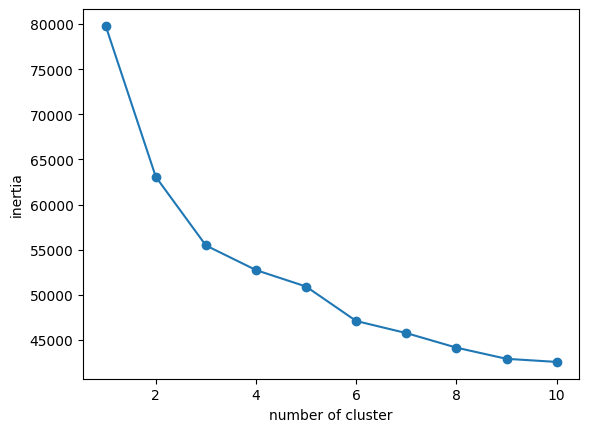

In [15]:
plt.plot(range(1,11),inertia,marker='o')
plt.xlabel('number of cluster')
plt.ylabel('inertia')
plt.show()

check cluster size

In [16]:
kmean = KMeans(n_clusters=3,random_state=40)
kmean.fit(clean_x)



KMeans(n_clusters=3, random_state=40)

In [17]:
clean_x['cluster'] =  kmean.predict(clean_x)
clean_x['cluster']

0       0
1       2
2       0
3       2
4       0
       ..
7038    1
7039    1
7040    0
7041    0
7042    1
Name: cluster, Length: 7043, dtype: int32

In [18]:
pd.crosstab(clean_x['cluster'],df['Churn'],normalize='index')*100

Churn,No,Yes
cluster,,
0,49.562904,50.437096
1,83.512881,16.487119
2,91.655687,8.344313


check accuracy using silhouette_score

In [19]:
from sklearn.metrics import silhouette_score
score = silhouette_score(clean_x.drop('cluster',axis=1),clean_x['cluster'])
print(score)

0.17192329215012322


In [20]:
# less score because it is churn dataset and have not good cluster

In [21]:
# cluster 0 = tenure low, montly spending = high and churn rate = 50%
# cluster 1 = tenure high, monthly spending = high and churn rate = 18%
# cluster 2 = tenure medium, monthly spending = low and churn rate 8%

In [22]:
persona_model = kmeanpersonapredict(
    kmeans_model = kmean,
    persona_map = CLUSTER_PERSONA_MAP
)



In [23]:
ml_pipeline = Pipeline([
    ('clean',preprocessing),
    ('model',persona_model)
])

In [24]:
ml_pipeline.fit(df)

Pipeline(steps=[('clean',
                 ColumnTransformer(transformers=[('Totalcharge',
                                                  Pipeline(steps=[('convert',
                                                                   FunctionTransformer(feature_names_out=<function get_new_num_names at 0x000001BCA17AD4E0>,
                                                                                       func=<function cat_to_num at 0x000001BCA17AD300>)),
                                                                  ('imput',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['TotalCharges']),
                                                 ('binary',
                                                  Pipeline(step

In [25]:
ml_pipeline.predict(df)

array(['new risk / not loyal', 'Highly loyal budget',
       'new risk / not loyal', ..., 'new risk / not loyal',
       'new risk / not loyal', 'Loyal premium'],
      shape=(7043,), dtype=object)

Test pipeline using raw data

In [26]:
sample_data = pd.DataFrame({'customerID':['7590-VHVEG'], 'gender':['Female'], 'SeniorCitizen':[0], 'Partner':['Yes'], 'Dependents':['No'],
       'tenure':[1], 'PhoneService':['No'], 'MultipleLines':['No phone service'], 'InternetService':['DSL'],
       'OnlineSecurity':['No'], 'OnlineBackup':['Yes'], 'DeviceProtection':['No'], 'TechSupport':['No'],
       'StreamingTV':['No'], 'StreamingMovies':['No'], 'Contract':['Month-to-month'], 'PaperlessBilling':['Yes'],
       'PaymentMethod':['Electronic check'], 'MonthlyCharges':[29.85], 'TotalCharges':[29.85]
})
sample_data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


In [27]:
predict = ml_pipeline.predict(sample_data)
predict

array(['new risk / not loyal'], dtype=object)

Save pipeline

In [28]:
file_name = "customer_type_ml_pipeline.pkl"
file_path = os.path.join(ML_MODELS,file_name)
file_path

'c:\\Users\\hamen\\OneDrive\\Desktop\\ml_project\\Telco_Customer_Churn_ML_Project\\ML_Pipelines\\customer_type_ml_pipeline.pkl'

In [29]:
joblib.dump(ml_pipeline,file_path)

['c:\\Users\\hamen\\OneDrive\\Desktop\\ml_project\\Telco_Customer_Churn_ML_Project\\ML_Pipelines\\customer_type_ml_pipeline.pkl']